In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import seaborn as sns

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speed up development. 

In [3]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("../data/kg_train.csv",encoding='latin-1')

# Reduce the training set to speed up development. 
# Modify for final system
data = data.head(1000)
print(data.shape)
data.fillna("",inplace=True)

(1000, 2)


0: Ham; 1: Spam

In [4]:
data.head()

,text,label
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1
1,Will do.,0
2,Nora--Cheryl has emailed dozens of memos about...,0
3,Dear Sir=2FMadam=2C I know that this proposal ...,1
4,fyi,0


### Let's divide the training and test set into two partitions

In [5]:
# Your code
X = data.drop('label', axis=1)
y = data['label']
print(X)
print(y)

                                                  text
0    DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...
1                                             Will do.
2    Nora--Cheryl has emailed dozens of memos about...
3    Dear Sir=2FMadam=2C I know that this proposal ...
4                                                  fyi
..                                                 ...
995  So what's the latest? It sounds contradictory ...
996  TRANSFER OF 36,759,000.00 MILLION POUNDS TO YO...
997  Barb I will call to explain. Are you back in t...
998    Yang on travelNot free tonite.May work tomorrow
999  sbwhoeopSunday February 21 2010 7:42 PMHShaunH...

[1000 rows x 1 columns]
0      1
1      0
2      0
3      1
4      0
      ..
995    0
996    1
997    0
998    0
999    0
Name: label, Length: 1000, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X original shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"y original shape: {y.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X original shape: (1000, 1)
X_train shape: (800, 1)
X_test shape: (200, 1)
y original shape: (1000,)
y_train shape: (800,)
y_test shape: (200,)


## Data Preprocessing

In [7]:
import string
from nltk.corpus import stopwords
print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

In [8]:
# Your code
# Create a function to clean the html code 
def clean_html(text):
    text = re.sub(r"<script.*?>.*?</script>", " ", text, flags=re.DOTALL | re.IGNORECASE) # Remove JavaScript comments
    text = re.sub(r"<style.*?>.*?</style>", " ", text, flags=re.DOTALL | re.IGNORECASE) # Remove CSS comments
    text = re.sub(r"<!--.*?-->", " ", text, flags=re.DOTALL) # Remove HTML comments
    text = re.sub(r"<[^>]+>", " ", text) # Remove tags

    return text


In [9]:
# Apply the html cleaning function to X_train and X_test
X_train["text"] = X_train["text"].apply(clean_html)
print(X_train.head())

X_test["text"] = X_test["text"].apply(clean_html)
print(X_test.head())

                                                  text
29   ----------- REGARDS, MR NELSON SMITH.KINDLY RE...
535  I have not been able to reach oscar this am. W...
695  ; Huma Abedin B6I'm checking with Pat on the 5...
557  I can have it announced here on Monday - can't...
836      BANK OF AFRICAAGENCE SAN PEDRO14 BP 1210 S...
                                                  text
521  Dear Sir=2C I wish you go through this offer t...
737  To take your mind off the Balkans for a second...
740                       Pls keep the updates coming!
660    CHRIST BETHEL HOSPITAL 11 RUE ABOBOTE,ABIDJA...
411  sbwhoeopFriday February 5 2010 7:11 AMHRe: Bra...


- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters
 
- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [10]:
# Your code
# Create a function to clean the text 
def clean_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) # Remove special characters
    text = re.sub(r"\d+", " ", text) # Remove numbers
    text = re.sub(r"\s+[a-zA-Z]\s+", " ", text) # Remove all single characters
    text = re.sub(r"\^[a-zA-Z]\s+", " ", text) # Remove single characters from the start
    text = re.sub(r"\s+", " ", text) # Substitute multiple spaces with a single space
    text = re.sub(r"^b\s+", " ", text) # Remove prefixed 'b'
    text = text.lower() # Convert to lowercase

    return text

In [11]:
# Apply the text cleaning function to X_train and X_test
X_train["text"] = X_train["text"].apply(clean_text)
print(X_train.head())

X_test["text"] = X_test["text"].apply(clean_text)
print(X_test.head())

                                                  text
29    regards mr nelson smith kindly reply me on my...
535  i have not been able to reach oscar this am we...
695   huma abedin i checking with pat on the will w...
557   i can have it announced here on monday can today
836   bank of africaagence san pedro bp san pedro c...
                                                  text
521  dear sir i wish you go through this offer to c...
737  to take your mind off the balkans for second s...
740                       pls keep the updates coming 
660   christ bethel hospital rue abobote abidjan iv...
411  sbwhoeopfriday february amhre bravo brava issu...


## Now let's work on removing stopwords
Remove the stopwords.

In [12]:
# Your code
def remove_stopwords(text):
    processed_docs = []
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    for word in tokens:
        if word not in stop_words:
            processed_docs.append(word)
    return ' '.join(processed_docs)


In [13]:
# Apply the removing stopwords function to X_train and X_test
X_train["text"] = X_train["text"].apply(clean_text)
print(X_train.head())

X_test["text"] = X_test["text"].apply(clean_text)
print(X_test.head())

                                                  text
29    regards mr nelson smith kindly reply me on my...
535  i have not been able to reach oscar this am we...
695   huma abedin checking with pat on the will wor...
557   i can have it announced here on monday can today
836   bank of africaagence san pedro bp san pedro c...
                                                  text
521  dear sir wish you go through this offer to con...
737  to take your mind off the balkans for second s...
740                       pls keep the updates coming 
660   christ bethel hospital rue abobote abidjan iv...
411  sbwhoeopfriday february amhre bravo brava issu...


In [14]:
X_test.loc[740, 'text']

'pls keep the updates coming '

## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [15]:
# Your code
def get_wordnet_pos(text):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([text])[0][1][0]#  Get POS tag's first character (e.g., 'N' from 'NN')
    #Maps it to a WordNet-compatible tag
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    
    return tag_dict.get(tag, wordnet.NOUN) # returns the word type (Noun if we have not found)

In [16]:
wordnet_lemma  = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    lemmatized = [wordnet_lemma.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return ' '.join(lemmatized)

In [17]:
# Apply the lemmatization function to X_train and X_test
X_train["text"] = X_train["text"].apply(lemmatize_text)
print(X_train["text"].head())

X_test["text"] = X_test["text"].apply(lemmatize_text)
print(X_test["text"].head())

29     regard mr nelson smith kindly reply me on my p...
535    i have not been able to reach oscar this am we...
695    huma abedin checking with pat on the will work...
557     i can have it announced here on monday can today
836    bank of africaagence san pedro bp san pedro co...
Name: text, dtype: object
521    dear sir wish you go through this offer to con...
737    to take your mind off the balkan for second se...
740                           pls keep the update coming
660    christ bethel hospital rue abobote abidjan ivo...
411    sbwhoeopfriday february amhre bravo brava issu...
Name: text, dtype: object


## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

In [18]:
# Your code
spam_data = data[data["label"] == 1]["text"]
ham_data  = data[data["label"] == 0]["text"]

from collections import Counter

def get_top_words(text_series, n=10):
    # Join all texts into one big string, then split into words
    all_words = " ".join(text_series).split()
    # Count occurrences of each word
    word_counts = Counter(all_words)
    # Return the n most common as a DataFrame
    return pd.DataFrame(word_counts.most_common(n), columns=["word", "count"])

top_spam = get_top_words(spam_data, n=10)
top_ham  = get_top_words(ham_data,  n=10)

print("=== TOP 10 SPAM WORDS ===")
print(top_spam)

print("\n=== TOP 10 HAM WORDS ===")
print(top_ham)


=== TOP 10 SPAM WORDS ===
   word  count
0   the   5676
1    to   4688
2    of   4118
3   and   3234
4    in   2672
5     I   2633
6   you   2273
7  this   2010
8     a   1939
9   for   1685

=== TOP 10 HAM WORDS ===
   word  count
0   the   1593
1    to   1039
2    of    782
3   and    781
4     a    591
5    in    540
6  that    371
7    is    353
8   for    344
9    on    283


## Extra features

In [19]:
# We add to the original dataframe two additional indicators (money symbols and suspicious words).
money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])

X_train['money_mark'] = X_train['text'].str.contains(money_simbol_list)*1
X_train['suspicious_words'] = X_train['text'].str.contains(suspicious_words)*1
X_train['text_len'] = X_train['text'].apply(lambda x: len(x)) 

X_test['money_mark'] = X_test['text'].str.contains(money_simbol_list)*1
X_test['suspicious_words'] = X_test['text'].str.contains(suspicious_words)*1
X_test['text_len'] = X_test['text'].apply(lambda x: len(x)) 

X_train.head()

,text,money_mark,suspicious_words,text_len
29,regard mr nelson smith kindly reply me on my p...,0,0,88
535,i have not been able to reach oscar this am we...,0,0,93
695,huma abedin checking with pat on the will work...,0,0,124
557,i can have it announced here on monday can today,0,0,48
836,bank of africaagence san pedro bp san pedro co...,1,1,1555


## How would work the Bag of Words with Count Vectorizer concept?

In [20]:
# Your code
# Create the Bag of Words model
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train['text'])
X_test_bow = vectorizer.transform(X_test['text'])

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Feature names:", vectorizer.get_feature_names_out())
print("Matrix shape:", X_train_bow.shape)
print("Matrix type:", type(X_train_bow))
print("Document-Term Matrix:\n", X_train_bow.toarray())

Vocabulary size: 28161
Feature names: ['aa' 'aaa' 'aabeiawaeaambiqaceqedeqh' ... 'zzz' 'zzzahbxntxe' 'zzzj']
Matrix shape: (800, 28161)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Document-Term Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [24]:
# Your code
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train['text'])
X_test_tfidf = tfidf.transform(X_test['text'])

# Print the shape of the dataset
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape: ", X_test_tfidf.shape)

X_train_tfidf shape: (800, 28161)
X_test_tfidf shape:  (200, 28161)


## And the Train a Classifier?

In [28]:
# Your code
# Use LogisticRegression as classifier
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = lr_model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

Accuracy: 0.9500
              precision    recall  f1-score   support

         Ham       0.94      0.98      0.96       125
        Spam       0.97      0.89      0.93        75

    accuracy                           0.95       200
   macro avg       0.95      0.94      0.95       200
weighted avg       0.95      0.95      0.95       200



In [31]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[123   2]
 [  8  67]]


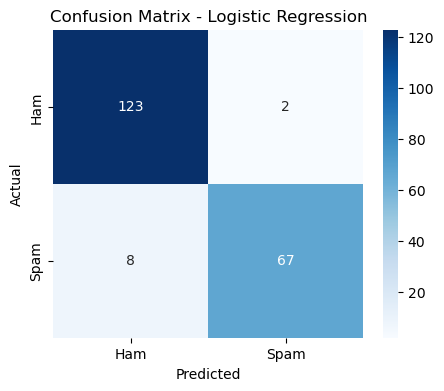

In [36]:
# Confusion Matrix (Heatmap)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The model has an excelent accuracy (0.95), however this is not the best metric considering the dataset is not balanced.
It has a good precision for both categories, however a lower recall for spam email, meaning it is failing in recognizing some spam emails.

### Extra Task - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

The classifier can not be changed!!! It must be the MultinimialNB with default parameters!

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

In [23]:
# Your code